###### 132_4_practical_lcm_period_filter.ipynb

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

In [123]:
plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

In [124]:
df = pd.read_csv("dataset/lcm_period_filter_practice.csv",
                 encoding="utf-8-sig")

In [125]:
df

,defect_id,site,customer,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,comment
0,D001,SUS,Honda,J69P,Buck-IC,3,120000,2026-06-30 23:50:00+09:00,回答済,期間外_前日夜
1,D002,WSE,Honda,310D,Coil,1,98000,2026-07-01 00:10:00+09:00,回答済,期間開始直後
2,D003,GSE,Mitsubishi,310D,NTF,1,87000,2026-07-01 09:30:00+09:00,回答済,朝発生
3,D004,META,Honda,J69P,Buck-IC,2,150000,2026-07-02 14:20:00+09:00,調査中,午後発生
4,D005,MEAX,Mitsubishi,36WA,Coil,4,110000,2026-07-02 18:45:00+09:00,回答済,夕方発生
5,D006,MELAC,Honda,3BVT,NTF,1,76000,2026-07-03 08:15:00+09:00,回答済,午前発生
6,D007,SUS,Honda,36WA,Buck-IC,5,125000,2026-07-03 22:10:00+09:00,回答済,夜間発生
7,D008,WSE,Mitsubishi,J69P,Coil,2,99000,2026-07-04 01:30:00+09:00,調査中,深夜発生
8,D009,GSE,Honda,310D,Coil,3,88000,2026-07-04 11:40:00+09:00,回答済,昼前発生
9,D010,META,Mitsubishi,36WA,Buck-IC,2,151000,2026-07-05 15:05:00+09:00,回答済,午後発生


In [126]:
df.dtypes

defect_id            str
site                 str
customer             str
model                str
defect_category      str
defect_qty           str
inspection_qty     int64
occ_at_jst           str
status               str
comment              str
dtype: object

In [127]:
df["defect_qty_num"] = pd.to_numeric(
    df["defect_qty"],
    errors="coerce",
)

In [128]:
df["defect_qty_num"]

0     3.0
1     1.0
2     1.0
3     2.0
4     4.0
5     1.0
6     5.0
7     2.0
8     3.0
9     2.0
10    1.0
11    1.0
12    2.0
13    4.0
14    1.0
15    2.0
16    0.0
17    NaN
Name: defect_qty_num, dtype: float64

In [129]:
df[
    [
        "defect_id",
        "defect_qty",
        "defect_qty_num",
    ]
].dtypes

defect_id             str
defect_qty            str
defect_qty_num    float64
dtype: object

In [130]:
df["occ_at_jst_raw"] = df["occ_at_jst"]

In [131]:
df["occ_at_jst_clean"] = (
    df["occ_at_jst"]
    .astype("string")
    .str.strip()
)

In [132]:
df["occ_at_jst_dt"] = pd.to_datetime(
    df["occ_at_jst_clean"],
    errors="coerce",
)

In [133]:
df["occ_at_jst_dt"]

0    2026-06-30 23:50:00+09:00
1    2026-07-01 00:10:00+09:00
2    2026-07-01 09:30:00+09:00
3    2026-07-02 14:20:00+09:00
4    2026-07-02 18:45:00+09:00
5    2026-07-03 08:15:00+09:00
6    2026-07-03 22:10:00+09:00
7    2026-07-04 01:30:00+09:00
8    2026-07-04 11:40:00+09:00
9    2026-07-05 15:05:00+09:00
10   2026-07-06 19:25:00+09:00
11   2026-07-07 23:55:00+09:00
12   2026-07-08 00:00:00+09:00
13   2026-07-08 10:20:00+09:00
14                         NaT
15                         NaT
16   2026-07-05 06:10:00+09:00
17   2026-07-06 13:45:00+09:00
Name: occ_at_jst_dt, dtype: datetime64[us, UTC+09:00]

In [134]:
df_data_ng = df[
    df["occ_at_jst_dt"].isna()
].copy()
df_data_ng

,defect_id,site,customer,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,comment,defect_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
14,D015,GSE,Honda,J69P,NTF,1,89000,NaN,未回答,日時空欄,1.0,NaN,<NA>,NaT
15,D016,META,Honda,3BVT,Coil,2,152000,日付不正,調査中,日時不正,2.0,日付不正,日付不正,NaT


In [135]:
df["defect_qty_num"]

0     3.0
1     1.0
2     1.0
3     2.0
4     4.0
5     1.0
6     5.0
7     2.0
8     3.0
9     2.0
10    1.0
11    1.0
12    2.0
13    4.0
14    1.0
15    2.0
16    0.0
17    NaN
Name: defect_qty_num, dtype: float64

In [136]:
df_qty_ng = df[
    df["defect_qty_num"].isna()
].copy()
df_qty_ng

,defect_id,site,customer,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,comment,defect_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
17,D018,MELAC,Honda,36WA,Coil,未入力,79000,2026-07-06 13:45:00+09:00,調査中,数量未入力,NaN,2026-07-06 13:45:00+09:00,2026-07-06 13:45:00+09:00,2026-07-06 13:45:00+09:00


In [137]:
df["occ_at_jst_dt"]

0    2026-06-30 23:50:00+09:00
1    2026-07-01 00:10:00+09:00
2    2026-07-01 09:30:00+09:00
3    2026-07-02 14:20:00+09:00
4    2026-07-02 18:45:00+09:00
5    2026-07-03 08:15:00+09:00
6    2026-07-03 22:10:00+09:00
7    2026-07-04 01:30:00+09:00
8    2026-07-04 11:40:00+09:00
9    2026-07-05 15:05:00+09:00
10   2026-07-06 19:25:00+09:00
11   2026-07-07 23:55:00+09:00
12   2026-07-08 00:00:00+09:00
13   2026-07-08 10:20:00+09:00
14                         NaT
15                         NaT
16   2026-07-05 06:10:00+09:00
17   2026-07-06 13:45:00+09:00
Name: occ_at_jst_dt, dtype: datetime64[us, UTC+09:00]

In [138]:
df_work = df[
    df["occ_at_jst_dt"].notna()
].copy()
df_work

,defect_id,site,customer,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,comment,defect_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt
0,D001,SUS,Honda,J69P,Buck-IC,3,120000,2026-06-30 23:50:00+09:00,回答済,期間外_前日夜,3.0,2026-06-30 23:50:00+09:00,2026-06-30 23:50:00+09:00,2026-06-30 23:50:00+09:00
1,D002,WSE,Honda,310D,Coil,1,98000,2026-07-01 00:10:00+09:00,回答済,期間開始直後,1.0,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00
2,D003,GSE,Mitsubishi,310D,NTF,1,87000,2026-07-01 09:30:00+09:00,回答済,朝発生,1.0,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00
3,D004,META,Honda,J69P,Buck-IC,2,150000,2026-07-02 14:20:00+09:00,調査中,午後発生,2.0,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00
4,D005,MEAX,Mitsubishi,36WA,Coil,4,110000,2026-07-02 18:45:00+09:00,回答済,夕方発生,4.0,2026-07-02 18:45:00+09:00,2026-07-02 18:45:00+09:00,2026-07-02 18:45:00+09:00
5,D006,MELAC,Honda,3BVT,NTF,1,76000,2026-07-03 08:15:00+09:00,回答済,午前発生,1.0,2026-07-03 08:15:00+09:00,2026-07-03 08:15:00+09:00,2026-07-03 08:15:00+09:00
6,D007,SUS,Honda,36WA,Buck-IC,5,125000,2026-07-03 22:10:00+09:00,回答済,夜間発生,5.0,2026-07-03 22:10:00+09:00,2026-07-03 22:10:00+09:00,2026-07-03 22:10:00+09:00
7,D008,WSE,Mitsubishi,J69P,Coil,2,99000,2026-07-04 01:30:00+09:00,調査中,深夜発生,2.0,2026-07-04 01:30:00+09:00,2026-07-04 01:30:00+09:00,2026-07-04 01:30:00+09:00
8,D009,GSE,Honda,310D,Coil,3,88000,2026-07-04 11:40:00+09:00,回答済,昼前発生,3.0,2026-07-04 11:40:00+09:00,2026-07-04 11:40:00+09:00,2026-07-04 11:40:00+09:00
9,D010,META,Mitsubishi,36WA,Buck-IC,2,151000,2026-07-05 15:05:00+09:00,回答済,午後発生,2.0,2026-07-05 15:05:00+09:00,2026-07-05 15:05:00+09:00,2026-07-05 15:05:00+09:00


In [139]:
df_work["defect_qty_num"]

0     3.0
1     1.0
2     1.0
3     2.0
4     4.0
5     1.0
6     5.0
7     2.0
8     3.0
9     2.0
10    1.0
11    1.0
12    2.0
13    4.0
16    0.0
17    NaN
Name: defect_qty_num, dtype: float64

In [140]:
df_work["defect_qty_calc"] = (
    df_work["defect_qty_num"]
    .fillna(0)
    .astype(int)
)

In [141]:
df_work["defect_qty_calc"].

SyntaxError: invalid syntax (1139900978.py, line 1)

In [ ]:
start_date = pd.Timestamp(
    "2026-07-01 00:00:00",
    tz="Asia/Tokyo",
)

In [ ]:
end_date = pd.Timestamp(
      "2026-07-08 00:00:00",
      tz="Asia/Tokyo",
)

In [ ]:
df_work["occ_at_jst_dt"]

0    2026-06-30 23:50:00+09:00
1    2026-07-01 00:10:00+09:00
2    2026-07-01 09:30:00+09:00
3    2026-07-02 14:20:00+09:00
4    2026-07-02 18:45:00+09:00
5    2026-07-03 08:15:00+09:00
6    2026-07-03 22:10:00+09:00
7    2026-07-04 01:30:00+09:00
8    2026-07-04 11:40:00+09:00
9    2026-07-05 15:05:00+09:00
10   2026-07-06 19:25:00+09:00
11   2026-07-07 23:55:00+09:00
12   2026-07-08 00:00:00+09:00
13   2026-07-08 10:20:00+09:00
16   2026-07-05 06:10:00+09:00
17   2026-07-06 13:45:00+09:00
Name: occ_at_jst_dt, dtype: datetime64[us, UTC+09:00]

In [ ]:
df_period = df_work[
    (df_work["occ_at_jst_dt"] >= start_date)
    & (df_work["occ_at_jst_dt"] < end_date)
].copy()

df_period

,defect_id,site,customer,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,comment,defect_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt,defect_qty_calc
1,D002,WSE,Honda,310D,Coil,1,98000,2026-07-01 00:10:00+09:00,回答済,期間開始直後,1.0,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,1
2,D003,GSE,Mitsubishi,310D,NTF,1,87000,2026-07-01 09:30:00+09:00,回答済,朝発生,1.0,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,1
3,D004,META,Honda,J69P,Buck-IC,2,150000,2026-07-02 14:20:00+09:00,調査中,午後発生,2.0,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00,2026-07-02 14:20:00+09:00,2
4,D005,MEAX,Mitsubishi,36WA,Coil,4,110000,2026-07-02 18:45:00+09:00,回答済,夕方発生,4.0,2026-07-02 18:45:00+09:00,2026-07-02 18:45:00+09:00,2026-07-02 18:45:00+09:00,4
5,D006,MELAC,Honda,3BVT,NTF,1,76000,2026-07-03 08:15:00+09:00,回答済,午前発生,1.0,2026-07-03 08:15:00+09:00,2026-07-03 08:15:00+09:00,2026-07-03 08:15:00+09:00,1
6,D007,SUS,Honda,36WA,Buck-IC,5,125000,2026-07-03 22:10:00+09:00,回答済,夜間発生,5.0,2026-07-03 22:10:00+09:00,2026-07-03 22:10:00+09:00,2026-07-03 22:10:00+09:00,5
7,D008,WSE,Mitsubishi,J69P,Coil,2,99000,2026-07-04 01:30:00+09:00,調査中,深夜発生,2.0,2026-07-04 01:30:00+09:00,2026-07-04 01:30:00+09:00,2026-07-04 01:30:00+09:00,2
8,D009,GSE,Honda,310D,Coil,3,88000,2026-07-04 11:40:00+09:00,回答済,昼前発生,3.0,2026-07-04 11:40:00+09:00,2026-07-04 11:40:00+09:00,2026-07-04 11:40:00+09:00,3
9,D010,META,Mitsubishi,36WA,Buck-IC,2,151000,2026-07-05 15:05:00+09:00,回答済,午後発生,2.0,2026-07-05 15:05:00+09:00,2026-07-05 15:05:00+09:00,2026-07-05 15:05:00+09:00,2
10,D011,MEAX,Honda,3BVT,Coil,1,112000,2026-07-06 19:25:00+09:00,調査中,夜間発生,1.0,2026-07-06 19:25:00+09:00,2026-07-06 19:25:00+09:00,2026-07-06 19:25:00+09:00,1


In [ ]:
df_period["occ_at_jst_dt"]

1    2026-07-01 00:10:00+09:00
2    2026-07-01 09:30:00+09:00
3    2026-07-02 14:20:00+09:00
4    2026-07-02 18:45:00+09:00
5    2026-07-03 08:15:00+09:00
6    2026-07-03 22:10:00+09:00
7    2026-07-04 01:30:00+09:00
8    2026-07-04 11:40:00+09:00
9    2026-07-05 15:05:00+09:00
10   2026-07-06 19:25:00+09:00
11   2026-07-07 23:55:00+09:00
16   2026-07-05 06:10:00+09:00
17   2026-07-06 13:45:00+09:00
Name: occ_at_jst_dt, dtype: datetime64[us, UTC+09:00]

In [ ]:
df_period["occ_date_jst"] = df_period["occ_at_jst_dt"].dt.date

In [ ]:
df_period["occ_date_jst"]

1     2026-07-01
2     2026-07-01
3     2026-07-02
4     2026-07-02
5     2026-07-03
6     2026-07-03
7     2026-07-04
8     2026-07-04
9     2026-07-05
10    2026-07-06
11    2026-07-07
16    2026-07-05
17    2026-07-06
Name: occ_date_jst, dtype: object

In [ ]:
df_period["occ_at_jst_dt"]

1    2026-07-01 00:10:00+09:00
2    2026-07-01 09:30:00+09:00
3    2026-07-02 14:20:00+09:00
4    2026-07-02 18:45:00+09:00
5    2026-07-03 08:15:00+09:00
6    2026-07-03 22:10:00+09:00
7    2026-07-04 01:30:00+09:00
8    2026-07-04 11:40:00+09:00
9    2026-07-05 15:05:00+09:00
10   2026-07-06 19:25:00+09:00
11   2026-07-07 23:55:00+09:00
16   2026-07-05 06:10:00+09:00
17   2026-07-06 13:45:00+09:00
Name: occ_at_jst_dt, dtype: datetime64[us, UTC+09:00]

In [ ]:
df_period["occ_month_jst"] = df_period["occ_at_jst_dt"].dt.strftime("%Y-%m")
df_period["occ_month_jst"]

1     2026-07
2     2026-07
3     2026-07
4     2026-07
5     2026-07
6     2026-07
7     2026-07
8     2026-07
9     2026-07
10    2026-07
11    2026-07
16    2026-07
17    2026-07
Name: occ_month_jst, dtype: str

In [ ]:
df_period["occ_at_jst_dt"]

1    2026-07-01 00:10:00+09:00
2    2026-07-01 09:30:00+09:00
3    2026-07-02 14:20:00+09:00
4    2026-07-02 18:45:00+09:00
5    2026-07-03 08:15:00+09:00
6    2026-07-03 22:10:00+09:00
7    2026-07-04 01:30:00+09:00
8    2026-07-04 11:40:00+09:00
9    2026-07-05 15:05:00+09:00
10   2026-07-06 19:25:00+09:00
11   2026-07-07 23:55:00+09:00
16   2026-07-05 06:10:00+09:00
17   2026-07-06 13:45:00+09:00
Name: occ_at_jst_dt, dtype: datetime64[us, UTC+09:00]

In [ ]:
df_period["occ_hour_jst"] = df_period["occ_at_jst_dt"].dt.hour

In [ ]:
df_period["occ_hour_jst"]

1      0
2      9
3     14
4     18
5      8
6     22
7      1
8     11
9     15
10    19
11    23
16     6
17    13
Name: occ_hour_jst, dtype: int32

In [ ]:
df_period["occ_time_zone_jst"] = ""

In [ ]:
df_period["occ_time_zone_jst"]

1     深夜
2       
3       
4       
5       
6       
7     深夜
8       
9       
10      
11      
16      
17      
Name: occ_time_zone_jst, dtype: str

In [ ]:
df_period.loc[
    df_period["occ_hour_jst"].between(0, 5),
    "occ_time_zone_jst"
] = "深夜"

In [ ]:
df_period["occ_time_zone_jst"]

1     深夜
2       
3       
4       
5       
6       
7     深夜
8       
9       
10      
11      
16      
17      
Name: occ_time_zone_jst, dtype: str

In [ ]:
df_period.loc[
    df_period["occ_hour_jst"].between(6, 11),
    "occ_time_zone_jst"
] = "午前"

In [ ]:
df_period[
    [
        "occ_hour_jst",
        "occ_time_zone_jst"
    ]
]

,occ_hour_jst,occ_time_zone_jst
1,0,深夜
2,9,午前
3,14,
4,18,
5,8,午前
6,22,
7,1,深夜
8,11,午前
9,15,
10,19,


In [ ]:
df_period.loc[
    df_period["occ_hour_jst"].between(12, 17),
    "occ_time_zone_jst"
] = "午後"

In [ ]:
df_period[
    [
        "occ_hour_jst",
        "occ_time_zone_jst"
    ]
]

,occ_hour_jst,occ_time_zone_jst
1,0,深夜
2,9,午前
3,14,午後
4,18,
5,8,午前
6,22,
7,1,深夜
8,11,午前
9,15,午後
10,19,


In [ ]:
df_period.loc[
    df_period["occ_hour_jst"].between(18, 23),
    "occ_time_zone_jst"
] = "夜間"

In [ ]:
df_period[
    [
        "occ_hour_jst",
        "occ_time_zone_jst",
    ]
]

,occ_hour_jst,occ_time_zone_jst
1,0,深夜
2,9,午前
3,14,午後
4,18,夜間
5,8,午前
6,22,夜間
7,1,深夜
8,11,午前
9,15,午後
10,19,夜間


In [ ]:
df_site_summary = df_period.groupby(
    "site",
    as_index=False,    
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
    inspection_qty_sum=("inspection_qty", "sum")
)
df_site_summary

,site,defect_count,defect_qty_sum,inspection_qty_sum
0,GSE,2,4,175000
1,MEAX,3,5,335000
2,MELAC,3,2,233000
3,META,2,4,301000
4,SUS,1,5,125000
5,WSE,2,3,197000


In [ ]:
df_site_summary["ppm"] = (
    df_site_summary["defect_qty_sum"]
    / df_site_summary["inspection_qty_sum"]
    *1000000
).round(1)
df_site_summary

,site,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,GSE,2,4,175000,22.9
1,MEAX,3,5,335000,14.9
2,MELAC,3,2,233000,8.6
3,META,2,4,301000,13.3
4,SUS,1,5,125000,40.0
5,WSE,2,3,197000,15.2


In [ ]:
df_site_summary = df_site_summary.sort_values(
    "defect_qty_sum",
    ascending=False,
).reset_index(drop=True)
df_site_summary

,site,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,MEAX,3,5,335000,14.9
1,SUS,1,5,125000,40.0
2,GSE,2,4,175000,22.9
3,META,2,4,301000,13.3
4,WSE,2,3,197000,15.2
5,MELAC,3,2,233000,8.6


In [ ]:
df_period.head(2)

,defect_id,site,customer,model,defect_category,defect_qty,inspection_qty,occ_at_jst,status,comment,defect_qty_num,occ_at_jst_raw,occ_at_jst_clean,occ_at_jst_dt,defect_qty_calc,occ_date_jst,occ_month_jst,occ_hour_jst,occ_time_zone_jst
1,D002,WSE,Honda,310D,Coil,1,98000,2026-07-01 00:10:00+09:00,回答済,期間開始直後,1.0,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,2026-07-01 00:10:00+09:00,1,2026-07-01,2026-07,0,深夜
2,D003,GSE,Mitsubishi,310D,NTF,1,87000,2026-07-01 09:30:00+09:00,回答済,朝発生,1.0,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,2026-07-01 09:30:00+09:00,1,2026-07-01,2026-07,9,午前


In [ ]:
df_model_summary = df_period.groupby(
    "model",
    as_index=False
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
    inspection_qty_sum=("inspection_qty", "sum"),
)
df_model_summary

,model,defect_count,defect_qty_sum,inspection_qty_sum
0,310D,4,5,386000
1,36WA,4,11,465000
2,3BVT,2,2,188000
3,J69P,3,5,327000


In [ ]:
df_model_summary["ppm"] = (
    df_model_summary["defect_qty_sum"]
    / df_model_summary["inspection_qty_sum"]
    * 1000000
).round(1)

df_model_summary

,model,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,310D,4,5,386000,13.0
1,36WA,4,11,465000,23.7
2,3BVT,2,2,188000,10.6
3,J69P,3,5,327000,15.3


In [ ]:
df_model_summary = df_model_summary.sort_values(
    "defect_qty_sum",
    ascending=False,
).reset_index(drop=True)
df_model_summary

,model,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,36WA,4,11,465000,23.7
1,310D,4,5,386000,13.0
2,J69P,3,5,327000,15.3
3,3BVT,2,2,188000,10.6


In [ ]:
df_category_summary = df_period.groupby(
    "defect_category",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
    inspection_qty_sum=("inspection_qty", "sum"),
)

In [ ]:
df_category_summary

,defect_category,defect_count,defect_qty_sum,inspection_qty_sum
0,Buck-IC,4,9,539000
1,Coil,6,11,586000
2,NTF,3,3,241000


In [ ]:
df_category_summary["ppm"] = (
    df_category_summary["defect_qty_sum"]
    / df_category_summary["inspection_qty_sum"]
    * 1000000
).round(1)

In [ ]:
df_category_summary

,defect_category,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,Buck-IC,4,9,539000,16.7
1,Coil,6,11,586000,18.8
2,NTF,3,3,241000,12.4


In [ ]:
df_category_summary = df_category_summary.sort_values(
    "defect_qty_sum",
    ascending=False,
).reset_index(drop=True)

In [ ]:
df_category_summary

,defect_category,defect_count,defect_qty_sum,inspection_qty_sum,ppm
0,Coil,6,11,586000,18.8
1,Buck-IC,4,9,539000,16.7
2,NTF,3,3,241000,12.4


In [ ]:
df_period["occ_time_zone_jst"]

1     深夜
2     午前
3     午後
4     夜間
5     午前
6     夜間
7     深夜
8     午前
9     午後
10    夜間
11    夜間
16    午前
17    午後
Name: occ_time_zone_jst, dtype: str

In [ ]:
df_time_zone_summary = df_period.groupby(
    "occ_time_zone_jst",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)
df_time_zone_summary

,occ_time_zone_jst,defect_count,defect_qty_sum
0,午前,4,5
1,午後,3,4
2,夜間,4,11
3,深夜,2,3


In [ ]:
time_zone_order = [
    "深夜",
    "午前",
    "午後",
    "夜間",
]


In [146]:
df_time_zone_summary["time_zone_order"] = pd.Categorical(
    df_time_zone_summary["occ_time_zone_jst"],
    categories=time_zone_order,
    ordered=True,
)

In [142]:
df_time_zone_summary

,occ_time_zone_jst,defect_count,defect_qty_sum,time_zone_oredr,time_zone_order
0,午前,4,5,午前,午前
1,午後,3,4,午後,午後
2,夜間,4,11,夜間,夜間
3,深夜,2,3,深夜,深夜


In [150]:
time_zone_order = [
    "深夜",
    "午前",
    "午後",
    "夜間",
]

df_time_zone_summary["time_zone_order"] = pd.Categorical(
    df_time_zone_summary["occ_time_zone_jst"],
    categories=time_zone_order,
    ordered=True,
)

df_time_zone_summary = df_time_zone_summary.sort_values(
    "time_zone_order",
).drop(
    columns="time_zone_order",
).reset_index(drop=True)

df_time_zone_summary

,occ_time_zone_jst,defect_count,defect_qty_sum
0,深夜,2,3
1,午前,4,5
2,午後,3,4
3,夜間,4,11


In [148]:
df_time_zone_summary.columns.tolist()

['occ_time_zone_jst', 'defect_count', 'defect_qty_sum', 'time_zone_oredr']

In [149]:
df_time_zone_summary = df_time_zone_summary.drop(
    columns="time_zone_oredr"
)

In [151]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

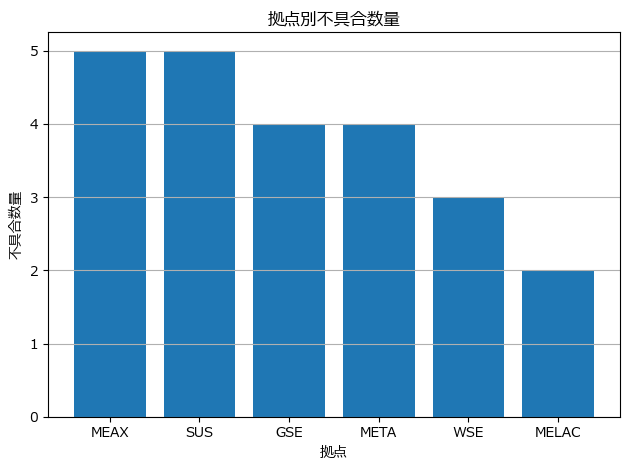

In [158]:
plt.bar(
    df_site_summary["site"],
    df_site_summary["defect_qty_sum"],
)

plt.title("拠点別不具合数量")
plt.xlabel("拠点")
plt.ylabel("不具合数量")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

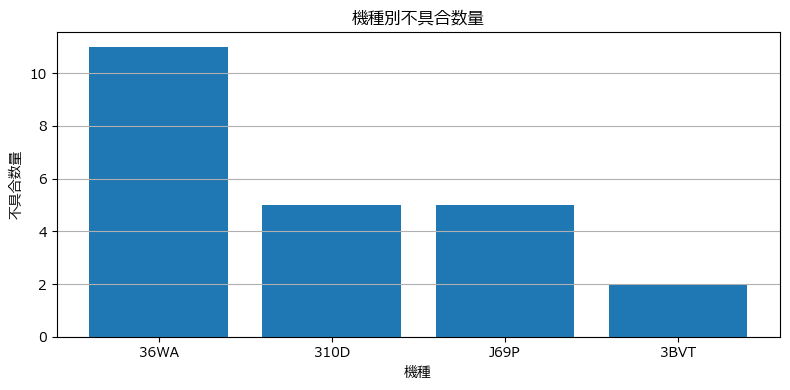

In [164]:
plt.figure(figsize=(8, 4))

plt.bar(
    df_model_summary["model"],
    df_model_summary["defect_qty_sum"]
)

plt.title("機種別不具合数量")
plt.xlabel("機種")
plt.ylabel("不具合数量")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [165]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

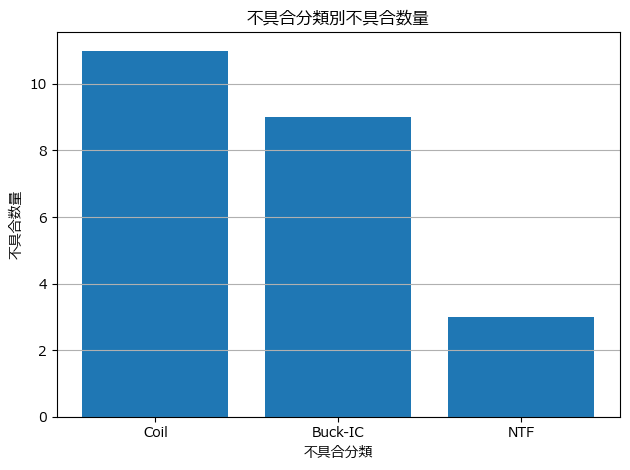

In [172]:
plt.bar(
    df_category_summary["defect_category"],
    df_category_summary["defect_qty_sum"],
)

plt.title("不具合分類別不具合数量")
plt.xlabel("不具合分類")
plt.ylabel("不具合数量")

plt.grid(axis="y")
plt.tight_layout()
plt.show()

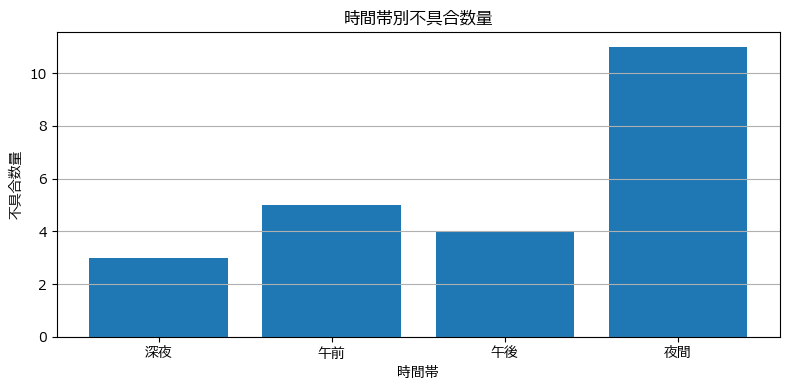

In [180]:
plt.figure(figsize=(8, 4))

plt.bar(
    df_time_zone_summary["occ_time_zone_jst"],
    df_time_zone_summary["defect_qty_sum"]
)

plt.title("時間帯別不具合数量")
plt.xlabel("時間帯")
plt.ylabel("不具合数量")

plt.grid(axis="y")
plt.tight_layout()
plt.show()